In [1]:
from pycromanager import Core

In [2]:
core = Core()

In [3]:
r = core.get_roi()
print(r.width, r.height, r.x, r.y)
core.set_roi(100,100,20,20)
r = core.get_roi()
print(r.width, r.height, r.x, r.y)

83 81 37 133
20 20 100 100


In [4]:
def obj_2_list(name):
    """Convert Java object to Python list."""
    return [name.get(i) for i in range(name.size())]

In [6]:
#obj_2_list(core.get_device_property_names("OSc-LSM"))

In [7]:
core.get_property("OSc-LSM","Dev1-Fermat Spiral Scan")

'No'

In [9]:
core.set_property("OSc-LSM","Dev1-Fermat Spiral Scan","Yes")
core.get_property("OSc-LSM","Dev1-Fermat Spiral Scan")

'Yes'

In [8]:
import time

In [9]:
from pycromanager import Studio
studio = Studio()

In [10]:
L = studio.live()

In [11]:
L.is_live_mode_on(), core.is_sequence_running()

(True, True)

In [25]:
print("Initial:", studio.live().is_live_mode_on(), core.is_sequence_running())

if core.is_sequence_running(): core.stop_sequence_acquisition()

core.start_continuous_sequence_acquisition(0)
# studio.live().set_live_mode_on(True)

print("After start:", studio.live().is_live_mode_on(), core.is_sequence_running())

for i in range(4):
    print(f"[{i+1}/4]:", studio.live().is_live_mode_on(), core.is_sequence_running())
    time.sleep(1)

core.stop_sequence_acquisition()

print("Final:", studio.live().is_live_mode_on(), core.is_sequence_running())

Initial: False False
After start: False True
[1/4]: False True
[2/4]: False True
[3/4]: False True
[4/4]: False True
Final: False False


In [30]:
#!uv pip list

In [ ]:
## editable install fails

In [12]:
import bh_spc
from bh_spc import spcm

In [13]:
import pprint
from collections import OrderedDict

In [40]:
spcm.init(r'C:\Program Files\Micro-Manager-2.0\spcm.ini')
#spcm.init(r'./spcm_single_5sec.ini')

In [41]:
mod_no = 0 # SPC 180NX
spcm.get_init_status(mod_no)

<InitStatus.OK: 0>

In [42]:
def print_params(params):
    params_ = OrderedDict(params)
    for k in params_:
        print(f'{k:<20} : {params_[k]:.3f}')

In [43]:
params = spcm.get_parameters(mod_no)
params_ = OrderedDict(params)

for k in params_:
    print(f'{k:<20} : {params_[k]:.3f}')

cfd_limit_low        : -29.412
cfd_limit_high       : 80.000
cfd_zc_level         : 12.850
cfd_holdoff          : 5.000
sync_zc_level        : -45.354
sync_freq_div        : 1.000
sync_holdoff         : 4.000
sync_threshold       : -9.804
tac_range            : 50.034
tac_gain             : 4.000
tac_offset           : 3.137
tac_limit_low        : 0.000
tac_limit_high       : 100.000
adc_resolution       : 12.000
ext_latch_delay      : 0.000
collect_time         : 10.000
display_time         : 1.000
repeat_time          : 10.000
stop_on_time         : 1.000
stop_on_ovfl         : 0.000
dither_range         : 128.000
count_incr           : 1.000
mem_bank             : 0.000
dead_time_comp       : 0.000
scan_control         : 0.000
routing_mode         : 0.000
tac_enable_hold      : 0.000
mode                 : 5.000
scan_size_x          : 1.000
scan_size_y          : 1.000
scan_rout_x          : 1.000
scan_rout_y          : 1.000
scan_polarity        : 7.000
scan_flyback         : 65537

In [33]:
def get_microtimes_MT(duration = 0.1, buf_size = 32768, mod_no=0):

    spcm.start_measurement(mod_no)
    start_time = time.monotonic()

    data = []  # Collect arrays of data into a list.
    while True:
        elapsed = time.monotonic() - start_time
        if elapsed >= duration:
            spcm.stop_measurement(mod_no)
            break
        buf = spcm.read_fifo_to_array(mod_no, buf_size)
        if len(buf):
            data.append(buf)
        if len(buf) < buf_size:  # We've read all there is to read.
            time.sleep(0.001)

    # Make sure to read the data that arrived after stopping (if you need it).
    while True:
        buf = spcm.read_fifo_to_array(mod_no, buf_size)
        if not len(buf):
            break
        data.append(buf)

    records = np.concatenate(data).view(np.uint32)
    len(records)

    had_gap = np.any(np.bitwise_and(records, 1 << 29))
    print("There was {} gap".format("a" if had_gap else "no"))

    photons = np.extract(np.bitwise_and(records, 0b1001 << 28) == 0, records)
    len(photons)

    max_12bit = (1 << 12) - 1  # 4095
    microtimes = np.bitwise_and(np.right_shift(photons, 16), max_12bit)

    # Reverse the microtimes by subtracting from the max value, because the raw
    # microtime is measured from photon to SYNC, not SYNC to photon.
    microtimes = max_12bit - microtimes
    
    return microtimes,photons


In [44]:
params.collect_time = 5 # sec
spcm.set_parameters(0, params)

In [25]:
#params.mode = 5
#spcm.set_parameters(0, params)

In [45]:
spcm.get_parameter(mod_no,spcm.ParID.MODE)

5

In [36]:
duration = spcm.get_parameter(mod_no,spcm.ParID.COLLECT_TIME)  # s
buf_size = 2**15  # Max number of 16-bit words in a single read.
duration, buf_size

(5.0, 32768)

In [37]:
import datetime
def print_time():
    print(datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

In [22]:
import numpy as np
from matplotlib import pyplot as plt

2026-04-09 13:11:56
There was no gap
181686 181686
23
2026-04-09 13:12:01
There was no gap
182720 182720
23
2026-04-09 13:12:06
There was no gap
181778 181778
24


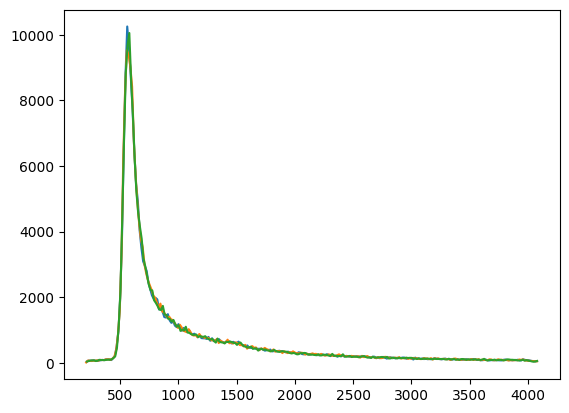

In [47]:

for k in range(2):
    print_time()
    mt,ph = get_microtimes_MT(duration,buf_size)
    print(len(mt),len(ph))
    x,h = np.histogram(mt,256)
    plt.plot(h[:-1],x)
    print(np.argmax(x))

2026-04-09 13:13:13
There was no gap
340410 340410
23
2026-04-09 13:13:18
There was no gap
341078 341078
24
2026-04-09 13:13:23
There was no gap
338607 338607
24


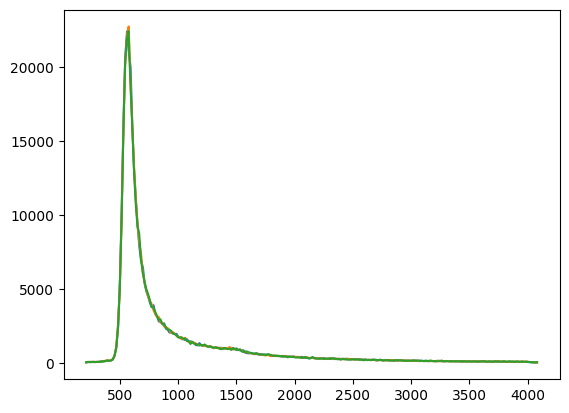

In [49]:

for k in range(3):
    print_time()
    mt,ph = get_microtimes_MT(duration,buf_size)
    print(len(mt),len(ph))
    x,h = np.histogram(mt,256)
    plt.plot(h[:-1],x)
    print(np.argmax(x))

2026-04-09 12:29:44
There was no gap
704 704
47
2026-04-09 12:29:46
There was no gap
684 684
1
2026-04-09 12:29:48
There was no gap
698 698
25


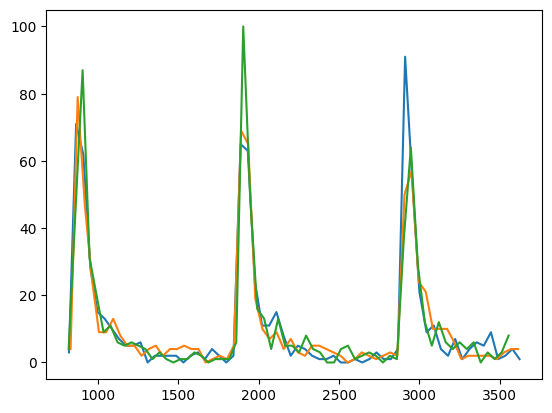

In [69]:

for k in range(3):
    print_time()
    mt,ph = get_microtimes_MT(duration,buf_size)
    print(len(mt),len(ph))
    x,h = np.histogram(mt,64)
    plt.plot(h[:-1],x)
    print(np.argmax(x))

2026-04-09 12:37:13
There was no gap
3 3
0
2026-04-09 12:37:15
There was no gap
7 7
0
2026-04-09 12:37:17
There was no gap
2 2
0


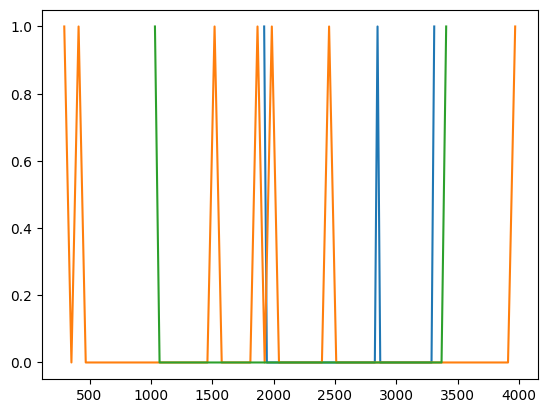

In [75]:

for k in range(3):
    print_time()
    mt,ph = get_microtimes_MT(duration,buf_size)
    print(len(mt),len(ph))
    x,h = np.histogram(mt,64)
    plt.plot(h[:-1],x)
    print(np.argmax(x))

In [78]:
params.sync_zc_level = 0.0
params.adc_resolution = 14
spcm.set_parameters(mod_no,params)

In [79]:
print_params(spcm.get_parameters(mod_no))

cfd_limit_low        : -29.412
cfd_limit_high       : 80.000
cfd_zc_level         : 12.850
cfd_holdoff          : 5.000
sync_zc_level        : 0.000
sync_freq_div        : 1.000
sync_holdoff         : 4.000
sync_threshold       : -9.804
tac_range            : 50.034
tac_gain             : 4.000
tac_offset           : 3.137
tac_limit_low        : 0.000
tac_limit_high       : 100.000
adc_resolution       : 12.000
ext_latch_delay      : 0.000
collect_time         : 2.000
display_time         : 1.000
repeat_time          : 10.000
stop_on_time         : 1.000
stop_on_ovfl         : 0.000
dither_range         : 128.000
count_incr           : 1.000
mem_bank             : 0.000
dead_time_comp       : 0.000
scan_control         : 0.000
routing_mode         : 0.000
tac_enable_hold      : 0.000
mode                 : 5.000
scan_size_x          : 1.000
scan_size_y          : 1.000
scan_rout_x          : 1.000
scan_rout_y          : 1.000
scan_polarity        : 7.000
scan_flyback         : 65537.00